# Split-stats summary

High/low (`AGNLUM`) split profiles for each profile type, with jackknife errorbars, shown for **BGS**, **LRG**, and **BGS+LRG** (deduplicated).

- **Blue** = low split, **red** = high split
- 90 GHz = solid, 150 GHz = dashed (shown on the same axes)
- One column per galaxy sample (BGS / LRG / BGS+LRG)
- Profiles are divided by the ring area `a` (as in `noah_scratch.ipynb`); errors are divided by `a` too.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
from astropy.table import Table
sys.path.append("../")
from boxeyFeedback import high_low_split
from jackknifing import jackknife_weighted_mean_cov_fast2

r = np.loadtxt('../radius.txt')
a = np.loadtxt('../area.txt')


def get_split_profile_stats(data, split_property):
    stats = {}
    for key1 in data.keys():
        for hl1 in [f'high_{split_property}', f'low_{split_property}']:
            d1 = data[data['split'] == hl1][key1]
            for key2 in data.keys():
                for hl2 in [f'high_{split_property}', f'low_{split_property}']:
                    d2 = data[data['split'] == hl2][key2]
                    if key1.startswith('profile_') and key2.startswith('profile_'):
                        w1 = np.ones(len(d1))
                        w2 = np.ones(len(d2))
                        m1, m2, c11, c22, c12 = jackknife_weighted_mean_cov_fast2(d1, w1, d2, w2)
                        stats[f'{key1}-{hl1}_mean'] = m1
                        stats[f'{key2}-{hl2}_mean'] = m2
                        stats[f'{key1}-{hl1}_cov'] = c11
                        stats[f'{key2}-{hl2}_cov'] = c22
                        stats[f'{key1}-{hl1}_{key2}-{hl2}_cov'] = c12
                    continue
    return stats

In [2]:
# read in data (modify this to read in your data)
datadir = '../data/'
datafn = f'{datadir}90.150.kappa_overlap_BgsLrgDuplicates.fits'
data = Table.read(datafn)
# apply cuts to data
data = data[data['Z'] < 1.3]
data = data[data['LOGM'] > 10.9]
data = data[data['LOGM'] < 12.5]
# make separate dataframes for bgs, lrg and bgs+lrg
bgs = data.copy()
bgs = bgs[bgs['galaxy_type']=='bgs']
lrg = data.copy()
lrg = lrg[lrg['galaxy_type']=='lrg']
bgs_lrg = data.copy()
bgs_lrg = bgs_lrg[bgs_lrg['duplicate']==False]
# box-ify data
split_property = 'AGNLUM'
n_boxes = 100
data_bgs = high_low_split(bgs, split_property, n_boxes=n_boxes)
data_lrg = high_low_split(lrg, split_property, n_boxes=n_boxes)
data_bgs_lrg = high_low_split(bgs_lrg, split_property, n_boxes=n_boxes)
# compute profile stats
profile_stats_bgs = get_split_profile_stats(data_bgs, split_property)
profile_stats_lrg = get_split_profile_stats(data_lrg, split_property)
profile_stats_bgs_lrg = get_split_profile_stats(data_bgs_lrg, split_property)

In [3]:
def get_split(profile_stats, profile_col, hl):
    """Return (mean, error) for one profile column and split, normalized by ring area.

    profile_stats : one of the per-sample stats dicts (bgs / lrg / bgs+lrg)
    profile_col   : e.g. 'profile_ringring2_90ghz' or 'profile_ring_kappa'
    hl            : 'high' or 'low'
    """
    base = f'{profile_col}-{hl}_{split_property}'
    mean = profile_stats[f'{base}_mean'] / a
    err = np.diag(profile_stats[f'{base}_cov']) ** 0.5 / a
    return mean, err


# (label, stats dict) for each galaxy sample, one column per case
cases = [('BGS', profile_stats_bgs),
         ('LRG', profile_stats_lrg),
         ('BGS+LRG', profile_stats_bgs_lrg)]

color = {'low': 'tab:blue', 'high': 'tab:red'}

## 90 & 150 GHz

Blue = low, red = high; 90 GHz solid, 150 GHz dashed. One column per galaxy sample.

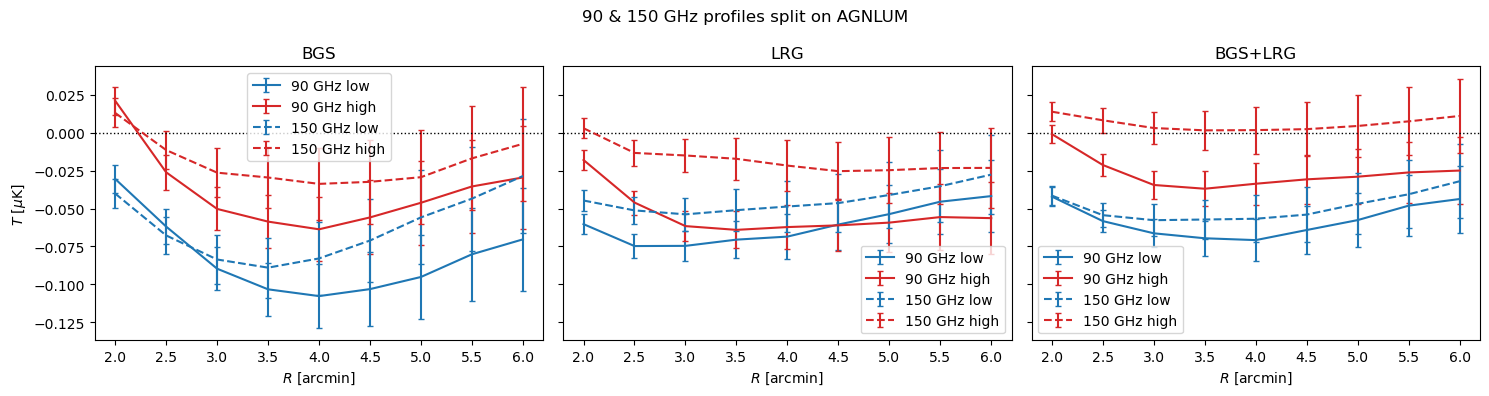

In [4]:
ghz_styles = [('profile_ringring2_90ghz', '-', '90 GHz'),
              ('profile_ringring2_150ghz', '--', '150 GHz')]

fig, axes = plt.subplots(1, len(cases), figsize=(5 * len(cases), 4), sharey=True)

for ax, (case_label, profile_stats) in zip(axes, cases):
    for profile_col, ls, freq_label in ghz_styles:
        for hl in ['low', 'high']:
            mean, err = get_split(profile_stats, profile_col, hl)
            ax.errorbar(r, mean, yerr=err, color=color[hl], linestyle=ls,
                        capsize=2, label=f'{freq_label} {hl}')
    ax.axhline(0, color='black', linewidth=1, linestyle=':')
    ax.set_xlabel(r'$R$ [arcmin]')
    ax.set_title(f'{case_label}')
    ax.legend()

axes[0].set_ylabel(r'$T$ [$\mu$K]')
fig.suptitle(f'90 & 150 GHz profiles split on {split_property}')
plt.tight_layout()
plt.show()

## Kappa

Blue = low, red = high. One column per galaxy sample.

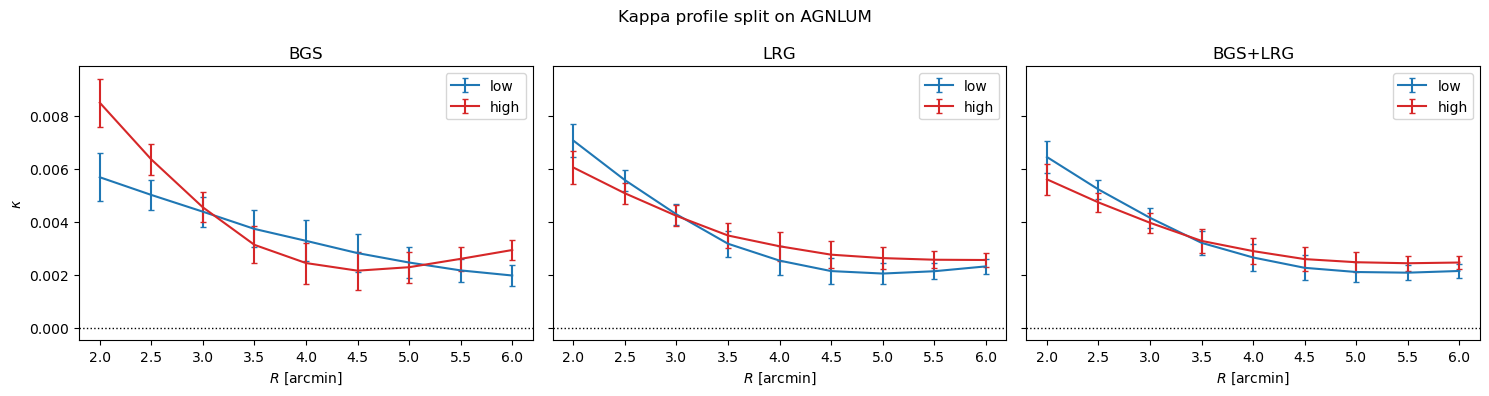

In [5]:
fig, axes = plt.subplots(1, len(cases), figsize=(5 * len(cases), 4), sharey=True)

for ax, (case_label, profile_stats) in zip(axes, cases):
    for hl in ['low', 'high']:
        mean, err = get_split(profile_stats, 'profile_ring_kappa', hl)
        ax.errorbar(r, mean, yerr=err, color=color[hl], capsize=2, label=hl)
    ax.axhline(0, color='black', linewidth=1, linestyle=':')
    ax.set_xlabel(r'$R$ [arcmin]')
    ax.set_title(f'{case_label}')
    ax.legend()

axes[0].set_ylabel(r'$\kappa$')
fig.suptitle(f'Kappa profile split on {split_property}')
plt.tight_layout()
plt.show()

## Best-fit tSZ + CIB model (90 + 150 GHz, jointly)

For each sample (BGS / LRG / BGS+LRG) and each AGN split (high / low) we fit a joint
tSZ + CIB model to the **90 and 150 GHz** profiles simultaneously, using the
jackknife covariance — including the **90&harr;150 cross-covariance** computed earlier.

The model (reproduced inline here, *not* imported from `tsz_cib_model/`) is a
beam-convolved Gaussian CIB minus a beam-convolved Gaussian tSZ, passed through
the same compensated ring filter (`bin_mat`) as the measured profiles. Five
parameters: `a_cib`, `a_tsz` (90 GHz amplitudes), `r_cib` (150/90 CIB rescaling),
and the CIB / tSZ Gaussian widths `sigma_cib`, `sigma_tsz`. The 150 GHz tSZ
amplitude is fixed at 0.62&times; the 90 GHz value (tSZ frequency scaling).

We minimize &chi;&sup2; = &Delta;&#7488; C&#8315;&sup1; &Delta;, where &Delta; is the
(stacked 90, 150) model&minus;data residual and C is the joint 18&times;18 jackknife
covariance. Parameters are bounded by the priors used in
`tsz_cib_model/analyze_90v150.py`.

Note: fitting is done in the profiles' **native (un-area-divided) units** to match
the model normalization; only the diagnostic plot below divides by `a` for display.

The radial **scale cuts** used in the fit are set by `fit_rmin` / `fit_rmax` at the top of the fit cell (e.g. `fit_rmax = 4.0` arcmin); the same cut is applied to both 90 and 150 GHz via `fit_mask`.

In [15]:
# ----------------------------------------------------------------------
# tSZ + CIB model, reproduced inline (NOT imported from tsz_cib_model/).
# Mirrors tsz_cib_model/theory_90v150.py.
# ----------------------------------------------------------------------

# frequencies and beams (FWHM = full-width half max)
fwhm1, fwhm2 = 1.42, 2.07  # 90 GHz, 150 GHz beam FWHM [arcmin]

def _fwhm_to_sigma(fwhm):
    return fwhm / (2 * np.sqrt(2 * np.log(2)))

sig1 = _fwhm_to_sigma(fwhm1)  # 90 GHz beam sigma
sig2 = _fwhm_to_sigma(fwhm2)  # 150 GHz beam sigma

# fine radial grid + compensated-ring binning matrix.
# (use r_grid / r_bin to avoid clobbering the notebook's `r` from radius.txt)
r_grid = np.linspace(0, 15, 500)
dr = r_grid[1] - r_grid[0]
r_bin = np.linspace(2, 6, 9, endpoint=True)  # matches radius.txt bins
bin_mat = np.zeros((len(r_bin), len(r_grid)))
for i in range(bin_mat.shape[0]):
    window = np.zeros(bin_mat.shape[1])
    r0, r1 = 1, r_bin[i]
    r2 = (2 * r_bin[i] ** 2 - r0 ** 2) ** 0.5
    window[np.where((r_grid > r0) & (r_grid <= r1))] = 1.0
    window[np.where((r_grid > r1) & (r_grid <= r2))] = -1.0
    window *= 2 * np.pi * r_grid * dr
    bin_mat[i, :] = window


def compute_binned_profiles(a_cib, a_tsz, r_cib, sigma_cib, sigma_tsz):
    """Return a length-18 vector: [90 GHz binned profile (9), 150 GHz binned profile (9)]."""
    profile1 = a_cib * np.exp(-r_grid ** 2 / 2 / (sigma_cib ** 2 + sig1 ** 2) ** 2)
    profile1 -= a_tsz * np.exp(-r_grid ** 2 / 2 / (sigma_tsz ** 2 + sig1 ** 2) ** 2)
    profile2 = a_cib * r_cib * np.exp(-r_grid ** 2 / 2 / (sigma_cib ** 2 + sig2 ** 2) ** 2)
    profile2 -= 0.62 * a_tsz * np.exp(-r_grid ** 2 / 2 / (sigma_tsz ** 2 + sig2 ** 2) ** 2)
    return np.concatenate([np.dot(bin_mat, profile1), np.dot(bin_mat, profile2)])


# ----------------------------------------------------------------------
# Assemble the joint 90+150 data vector and covariance for one split.
# ----------------------------------------------------------------------
def joint_data_and_cov(profile_stats, hl):
    """Stack 90 & 150 GHz means and build the joint covariance (incl. cross-cov).

    Returns (d, C) where d has length 18 and C is 18x18, in the profiles'
    native (un-area-divided) units. The full (uncut) vector is returned; scale
    cuts are applied at fit time via `fit_mask`.
    """
    base90 = f'profile_ringring2_90ghz-{hl}_{split_property}'
    base150 = f'profile_ringring2_150ghz-{hl}_{split_property}'
    cross_key = f'{base90}_profile_ringring2_150ghz-{hl}_{split_property}_cov'
    m90 = profile_stats[f'{base90}_mean']
    m150 = profile_stats[f'{base150}_mean']
    c90 = profile_stats[f'{base90}_cov']            # (9, 9) cov of 90 GHz mean
    c150 = profile_stats[f'{base150}_cov']          # (9, 9) cov of 150 GHz mean
    c_cross = profile_stats[cross_key]              # (9, 9) cov(90 mean, 150 mean)
    d = np.concatenate([m90, m150])
    C = np.block([[c90, c_cross],
                  [c_cross.T, c150]])
    return d, C

# ----------------------------------------------------------------------
# Scale cuts: choose which radial bins enter the fit (edit these).
# `r` holds the bin radii from radius.txt; the SAME cut is applied to 90 & 150.
# ----------------------------------------------------------------------
fit_rmin = 0.0    # arcmin: minimum fiducial radius used in the fits
fit_rmax = 10.0    # arcmin: maximum fiducial radius used in the fits
bin_mask = (r >= fit_rmin) & (r <= fit_rmax)        # (9,)  over radial bins
fit_mask = np.concatenate([bin_mask, bin_mask])     # (18,) over the joint 90+150 vector
print(f'fit uses radii {r[bin_mask]} arcmin '
      f'({int(bin_mask.sum())} bins x 2 freqs = {int(fit_mask.sum())} data points)')


# ----------------------------------------------------------------------
# Best-fit via chi2 minimization (priors from analyze_90v150.py as bounds).
# ----------------------------------------------------------------------
from scipy.optimize import minimize

param_names = ['a_cib', 'a_tsz', 'r_cib', 'sigma_cib', 'sigma_tsz']
bounds = [(0, 1), (0, 1), (1, 10), (0, 4), (0, 4)]


def fit_tsz_cib(d, C, mask, n_restarts=30, seed=0):
    """Minimize chi2 = diff @ Cinv @ diff over the masked scales, with random restarts."""
    d_cut = d[mask]
    C_cut = C[np.ix_(mask, mask)]   # keep only the in-cut rows/cols (incl. cross terms)
    Cinv = np.linalg.inv(C_cut)

    def neg_half_chi2(theta):
        diff = compute_binned_profiles(*theta)[mask] - d_cut
        return 0.5 * diff @ Cinv @ diff

    rng = np.random.default_rng(seed)
    best = None
    for _ in range(n_restarts):
        x0 = [rng.uniform(lo, hi) for lo, hi in bounds]
        res = minimize(neg_half_chi2, x0, method='L-BFGS-B', bounds=bounds)
        if best is None or res.fun < best.fun:
            best = res
    return best.x, 2 * best.fun  # (best-fit params, chi2_min)


# ----------------------------------------------------------------------
# Fit every sample x split and tabulate the results.
# ----------------------------------------------------------------------
import pandas as pd

dof = int(fit_mask.sum()) - len(param_names)
best_fits = {}
rows = []
for case_label, profile_stats in cases:
    for hl in ['low', 'high']:
        d, C = joint_data_and_cov(profile_stats, hl)
        theta, chi2 = fit_tsz_cib(d, C, fit_mask)
        best_fits[(case_label, hl)] = theta
        rows.append([case_label, hl, *theta, chi2, dof])

results = pd.DataFrame(rows, columns=['sample', 'split', *param_names, 'chi2', 'dof'])
results


fit uses radii [2.  2.5 3.  3.5 4.  4.5 5.  5.5 6. ] arcmin (9 bins x 2 freqs = 18 data points)


,sample,split,a_cib,a_tsz,r_cib,sigma_cib,sigma_tsz,chi2,dof
0,BGS,low,0.011748,0.246389,10.0,2.531890,1.357928,35.074519,13
1,BGS,high,0.108372,0.187535,1.0,0.770006,1.431369,33.612550,13
2,LRG,low,0.007671,0.262123,10.0,2.262877,1.021414,15.598920,13
3,LRG,high,0.006055,0.178821,10.0,1.471258,1.368416,21.893675,13
4,BGS+LRG,low,0.007378,0.199190,10.0,2.656179,1.115294,27.640483,13
5,BGS+LRG,high,0.092858,0.135607,1.0,0.740080,1.336230,15.820331,13


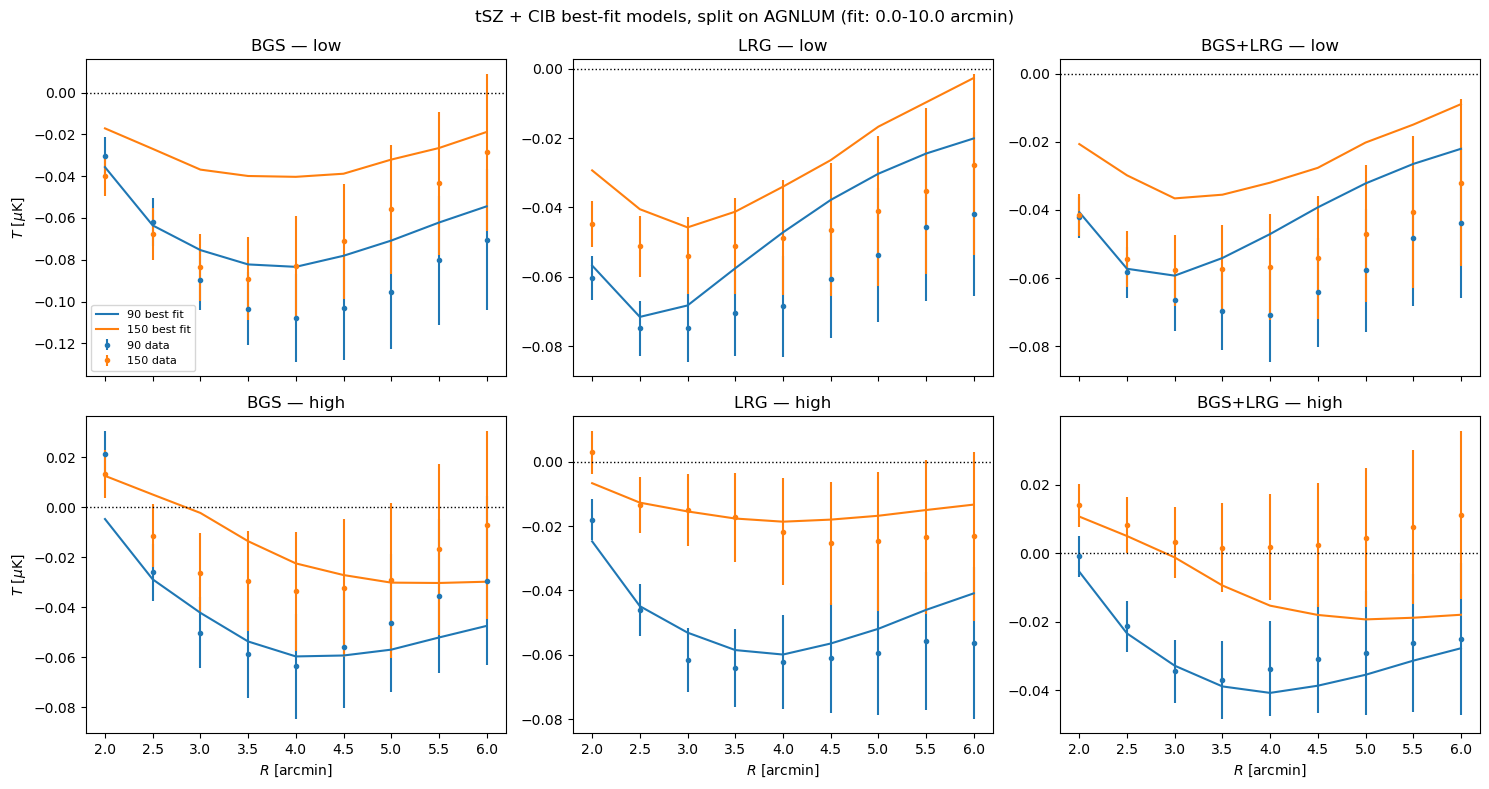

In [10]:
# Overlay best-fit model on the data (divided by area `a` for display).
# Shaded band marks the radial range actually used in the fit (fit_rmin..fit_rmax).
splits = ['low', 'high']
fig, axes = plt.subplots(len(splits), len(cases),
                         figsize=(5 * len(cases), 4 * len(splits)),
                         sharex=True)

for j, (case_label, profile_stats) in enumerate(cases):
    for i, hl in enumerate(splits):
        ax = axes[i, j]
        d, C = joint_data_and_cov(profile_stats, hl)
        err = np.diag(C) ** 0.5
        model = compute_binned_profiles(*best_fits[(case_label, hl)])
        # shaded = radii used in the fit
        # ax.axvspan(fit_rmin, fit_rmax, color='gray', alpha=0.10,
        #            label='fit range' if (i == 0 and j == 0) else None)
        # data points (90 = C0, 150 = C1), divided by area for display
        ax.errorbar(r, d[:9] / a, yerr=err[:9] / a, c='C0', ls='', marker='o', ms=3, label='90 data')
        ax.errorbar(r, d[9:] / a, yerr=err[9:] / a, c='C1', ls='', marker='o', ms=3, label='150 data')
        # best-fit model
        ax.plot(r, model[:9] / a, c='C0', label='90 best fit')
        ax.plot(r, model[9:] / a, c='C1', label='150 best fit')
        ax.axhline(0, color='black', linewidth=1, linestyle=':')
        ax.set_title(f'{case_label} \u2014 {hl}')
        if i == len(splits) - 1:
            ax.set_xlabel(r'$R$ [arcmin]')
        if j == 0:
            ax.set_ylabel(r'$T$ [$\mu$K]')
        if i == 0 and j == 0:
            ax.legend(fontsize=8)

fig.suptitle(f'tSZ + CIB best-fit models, split on {split_property} '
             f'(fit: {fit_rmin}-{fit_rmax} arcmin)')
plt.tight_layout()
plt.show()
